In [2]:
import matplotlib.pyplot as plt
from matplotlib import gridspec
import seaborn as sns
import pandas as pd
from tqdm.notebook import tqdm
from math import sin

from scipy.special import softmax
from scipy.spatial.distance import cdist
import numpy as np


[[ 1.  1.  1.  1.]
 [ 1.  2.  4.  8.]
 [ 1.  3.  9. 27.]
 [ 1.  4. 16. 64.]]
Коэффициенты полинома: [ 0.44292186  0.64400652 -0.09467642  0.00774804]
Значение средней в полиноме =  1.5822737080923595
Значение средней в функции =  1.5811388300841898


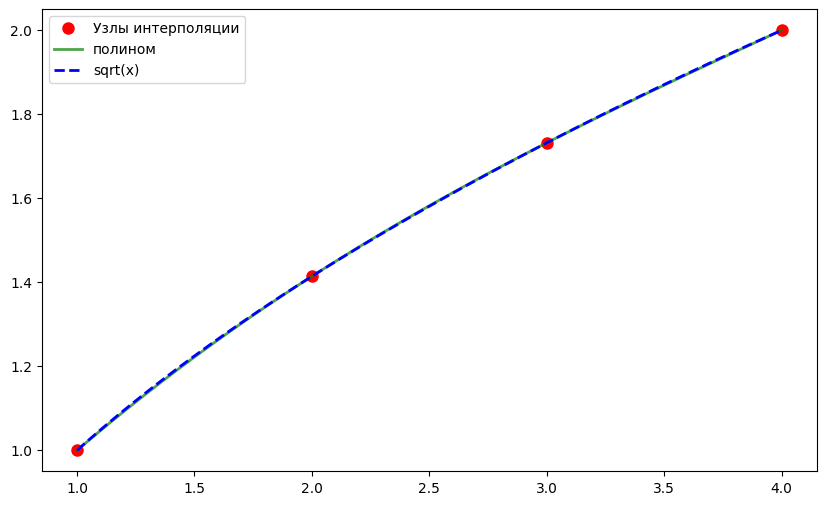

In [ ]:
def sqrtX(x):
    return np.sqrt(x)

x = np.linspace(1, 4, 4)
y1 = sqrtX(x)
n = len(x)
V = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        V[i][j] = x[i]**j


print(V)

coeffs = np.linalg.solve(V, y1)
print("Коэффициенты полинома:", coeffs)

def P(x_val):
    return sum(coeffs[i] * (x_val ** i) for i in range(n)) #полином

x_polin = np.linspace(1, 4, 1000)
y_polin = [P(xi) for xi in x_polin]

x_med = (x[0] + x[n-1])/2
print("Значение средней в полиноме = ", P(x_med))
print("Значение средней в функции = ", sqrtX(x_med))


plt.figure(figsize=(10, 6))
plt.plot(x, y1, 'ro', label='Узлы интерполяции', markersize=8)
plt.plot(x_polin, y_polin, 'g-', label='полином', linewidth=2, alpha=0.7)
plt.plot(x_polin, sqrtX(x_polin), 'b--', label='sqrt(x)', linewidth=2)
plt.legend()
plt.show()





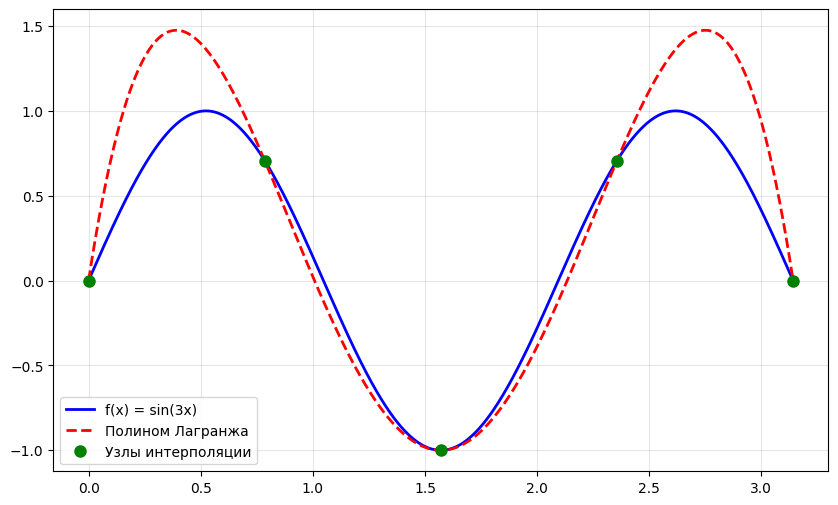

In [ ]:

def fun(x):
    return np.sin(3 * x)

def lagrange(x, y, xi):
    n = len(x)
    result = 0
    for i in range(n):
        li = 1
        for j in range(n):
            if j != i:
                li *= (xi - x[j]) / (x[i] - x[j])
        result += y[i] * li
    return result

x_nodes = np.linspace(0, np.pi, 5)
y_nodes = fun(x_nodes)

x_plot = np.linspace(0, np.pi, 1000)
y_exact = fun(x_plot)
y_lagrange = [lagrange(x_nodes, y_nodes, xi) for xi in x_plot]

plt.figure(figsize=(10, 6))
plt.plot(x_plot, y_exact, 'b-', label='f(x) = sin(3x)', linewidth=2)
plt.plot(x_plot, y_lagrange, 'r--', label='Полином Лагранжа', linewidth=2)
plt.plot(x_nodes, y_nodes, 'go', label='Узлы интерполяции', markersize=8)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


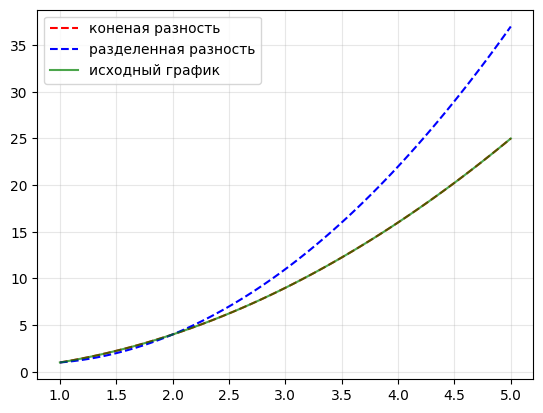

Результат в точке 7.0 - разд. 6.25 - конечн.


In [ ]:
x = [1,2,3,4,5]
y = [i**2 for i in x]

xi = 2.5
n = len(x)
h = x[1] - x[0]  

#конечные разности 
final_dif = np.zeros([n, n])
final_dif[:, 0] = y

for j in range(1,n,1):
    for i in range(0,n - j,1):
        final_dif[i][j] = (final_dif[i + 1][j - 1] - final_dif[i][j- 1])

def Newton_polin_final(x, delTa, xi, h):
    sum_polin = delTa[0][0]
    product = 1 
    
    for i in range(1, n):
        product *= (xi - x[i - 1])
        coeff = delTa[0][i]
        for j in range(2, i + 1):
            coeff /= (j * h)
        sum_polin += product * coeff
    
    return sum_polin

#разделенные разности
divided_dif = np.zeros([n, n])
divided_dif[:, 0] = y

for j in range(1,n,1):
    for i in range(0,n - j,1):
        divided_dif[i][j] = (divided_dif[i + 1][j - 1] - divided_dif[i][j- 1]) / (x[i + j] - x[i])


def Newton_polin_divided(x, delTa, xi, h):
    sum_polin = delTa[0][0]
    product = 1 
    
    for i in range(1, n):
        product *= (xi - x[i - 1])
        sum_polin += product * delTa[0][i] 
    
    return sum_polin



X_polin_final = np.linspace(1, 5, 100)
Y_polin_final = [Newton_polin_final(x, final_dif, val, h) for val in X_polin_final]

X_polin_divided = np.linspace(1, 5, 100)
Y_polin_divided = [Newton_polin_divided(x, final_dif, val, h) for val in X_polin_divided]


X_graph = np.linspace(1, 5, 100)
Y_graph = [i**2 for i in X_graph]

plt.plot(X_polin_final,Y_polin_final, 'r--', label='коненая разность')
plt.plot(X_polin_divided,Y_polin_divided, 'b--', label='разделенная разность')
plt.plot(X_graph,Y_graph, 'g-', alpha = 0.7, label='исходный график')

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

res1 = Newton_polin_divided(x, final_dif, xi, h)
res2 = Newton_polin_final(x, final_dif, xi, h)
print(f'Результат в точке {res1} - разд. {res2} - конечн.')


x = 1.5707963267948966:
  Точное:        0.0000000000
  Разд.разности: 0.5000000000
  Базисный:      0.0000000000


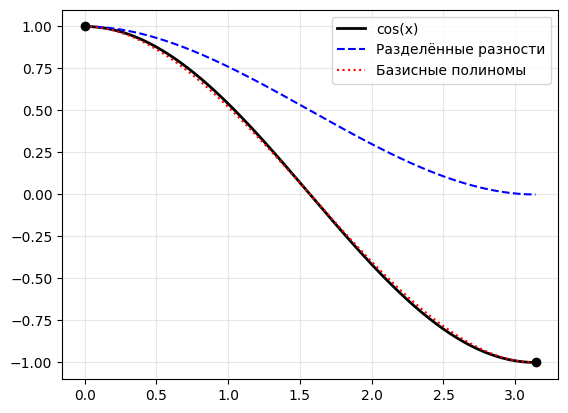

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def func(x): return np.cos(x)
def diffunc(x): return -np.sin(x)

x0, x1 = 0, np.pi
f0, f1 = func(x0), func(x1)
df0, df1 = diffunc(x0), diffunc(x1)
x_test = np.pi/2

# ========== МЕТОД 1: РАЗДЕЛЕННЫЕ РАЗНОСТИ ==========
z = [x0, x0, x1, x1]
n = 4
dd = np.zeros((n, n))
dd[0][0], dd[1][0], dd[2][0], dd[3][0] = f0, df0, f1, df1

for j in range(1, n):
    for i in range(n - j):
        if z[i] == z[i+j]:
            if j == 1: dd[i][j] = df0 if i < 2 else df1
            elif j == 2: dd[i][j] = -func(z[i])/2
            elif j == 3: dd[i][j] = func(z[i])/6
        else:
            dd[i][j] = (dd[i+1][j-1] - dd[i][j-1]) / (z[i+j] - z[i])

def P_newton(x):
    res = dd[0][0]
    prod = 1.0
    for i in range(1, n):
        prod *= (x - z[i-1])
        res += dd[0][i] * prod
    return res

# ========== МЕТОД 2: БАЗИСНЫЕ ПОЛИНОМЫ ==========
h = x1 - x0
def l0(x): return (x - x1) / (x0 - x1)
def l1(x): return (x - x0) / (x1 - x0)
dl0, dl1 = 1/(x0-x1), 1/(x1-x0)

def H0(x): return (1 - 2*(x-x0)*dl0) * l0(x)**2
def H1(x): return (1 - 2*(x-x1)*dl1) * l1(x)**2
def Hp0(x): return (x - x0) * l0(x)**2
def Hp1(x): return (x - x1) * l1(x)**2

def P_basis(x): return f0*H0(x) + f1*H1(x) + df0*Hp0(x) + df1*Hp1(x)

def P_cubic(x):
    t = (x - x0)/h
    return (2*t**3 - 3*t**2 + 1)*f0 + (t**3 - 2*t**2 + t)*h*df0 + (-2*t**3 + 3*t**2)*f1 + (t**3 - t**2)*h*df1

print(f"x = {x_test}:")
print(f"  Точное:        {func(x_test):.10f}")
print(f"  Разд.разности: {P_newton(x_test):.10f}")
print(f"  Базисный:      {P_basis(x_test):.10f}")

x_plot = np.linspace(x0, x1, 500)
y_exact = func(x_plot)
y_newton = np.array([P_newton(x) for x in x_plot])
y_basis = np.array([P_basis(x) for x in x_plot])

plt.plot(x_plot, y_exact, 'k-', lw=2, label='cos(x)')
plt.plot(x_plot, y_newton, 'b--', lw=1.5, label='Разделённые разности')
plt.plot(x_plot, y_basis, 'r:', lw=1.5, label='Базисные полиномы')
plt.plot([x0, x1], [f0, f1], 'ko', ms=6)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [11]:
import numpy as np
import matplotlib.pyplot as plt

def f(x): return 1/(x**2 + 1)

x_nodes = np.array([-3, -1.5, 0, 1.5, 3])
y_nodes = f(x_nodes)
n = len(x_nodes) - 1
x_eval = 1

# ========== КВАДРАТИЧНЫЙ СПЛАЙН С УСЛОВИЕМ b0 = 0 ==========
h = np.diff(x_nodes)
a = y_nodes[:-1]
b = np.zeros(n)
c = np.zeros(n)

# Построение системы для коэффициентов c
A = np.zeros((n, n))
B = np.zeros(n)

for i in range(n-1):
    A[i][i] = 2*h[i]
    A[i][i+1] = h[i]
    B[i] = 3*(a[i+1] - a[i])/h[i] - 3*(a[i] - a[i-1])/h[i-1] if i > 0 else 3*(a[i+1] - a[i])/h[i] - 3*b[0]

A[n-1][n-1] = 2*h[n-1]
B[n-1] = 3*(y_nodes[-1] - a[n-1])/h[n-1] - 3*b[n-1] if n-1 > 0 else 0

c = np.linalg.solve(A, B)

for i in range(n):
    b[i] = (a[i+1] - a[i])/h[i] - c[i]*h[i]

def quadratic_spline(x):
    for i in range(n):
        if x_nodes[i] <= x <= x_nodes[i+1]:
            dx = x - x_nodes[i]
            return a[i] + b[i]*dx + c[i]*dx**2
    return None

# ========== ЕСТЕСТВЕННЫЙ КУБИЧЕСКИЙ СПЛАЙН ==========
h = np.diff(x_nodes)
a = y_nodes
alpha = np.zeros(n)
for i in range(1, n):
    alpha[i] = 3/h[i]*(a[i+1] - a[i]) - 3/h[i-1]*(a[i] - a[i-1])

l = np.zeros(n+1)
mu = np.zeros(n)
z = np.zeros(n+1)
l[0] = 1
z[0] = 0

for i in range(1, n):
    l[i] = 2*(x_nodes[i+1] - x_nodes[i-1]) - h[i-1]*mu[i-1]
    mu[i] = h[i]/l[i]
    z[i] = (alpha[i] - h[i-1]*z[i-1])/l[i]

l[n] = 1
z[n] = 0
c = np.zeros(n+1)
b = np.zeros(n)
d = np.zeros(n)

for j in range(n-1, -1, -1):
    c[j] = z[j] - mu[j]*c[j+1]
    b[j] = (a[j+1] - a[j])/h[j] - h[j]*(c[j+1] + 2*c[j])/3
    d[j] = (c[j+1] - c[j])/(3*h[j])

def cubic_spline(x):
    for i in range(n):
        if x_nodes[i] <= x <= x_nodes[i+1]:
            dx = x - x_nodes[i]
            return a[i] + b[i]*dx + c[i]*dx**2 + d[i]*dx**3
    return None

# ========== ВЫЧИСЛЕНИЯ ==========
print(f"f({x_eval}) = {f(x_eval):.6f}")
print(f"Квадратичный сплайн в x=1: {quadratic_spline(x_eval):.6f}")
print(f"Кубический сплайн в x=1: {cubic_spline(x_eval):.6f}")

# ========== ВИЗУАЛИЗАЦИЯ ==========
x_plot = np.linspace(-3, 3, 500)
y_exact = f(x_plot)
y_quad = np.array([quadratic_spline(x) for x in x_plot])
y_cubic = np.array([cubic_spline(x) for x in x_plot])

plt.figure(figsize=(12, 8))
plt.plot(x_plot, y_exact, 'k-', lw=2, label='f(x) = 1/(x²+1)')
plt.plot(x_plot, y_quad, 'b--', lw=1.5, label='Квадратичный сплайн (b₀=0)')
plt.plot(x_plot, y_cubic, 'r:', lw=1.5, label='Естественный кубический сплайн')
plt.plot(x_nodes, y_nodes, 'ko', ms=8, label='Узлы')
plt.axvline(x=1, color='gray', ls='--', alpha=0.5)
plt.xlabel('x'), plt.ylabel('y')
plt.title('Сравнение квадратичного и кубического сплайнов')
plt.legend(), plt.grid(True, alpha=0.3)
plt.show()

IndexError: index 4 is out of bounds for axis 0 with size 4